In [24]:
#Install library
!pip install ultralytics roboflow opencv-python matplotlib

#Import library
import cv2
import matplotlib.pyplot as plt
import glob
import os
import yaml
from ultralytics import YOLO
%matplotlib inline

In [25]:
from roboflow import Roboflow

# Mengunduh dataset
rf = Roboflow(api_key="si6DMIe7RFPEEZxV39cI")
project = rf.workspace("yolov9-9uvwb").project("yolov9-fire-and-smoke-dataset")
version = project.version(1)

# Mengunduh dalam format YOLOv8
dataset = version.download("yolov8")
dataset_path = dataset.location
print("Lokasi dataset berhasil diunduh di:", dataset_path)

loading Roboflow workspace...
loading Roboflow project...
Lokasi dataset berhasil diunduh di: /content/YOLOv9-fire-and-smoke-dataset-1


In [26]:
import os

print(os.listdir(dataset_path))

['README.roboflow.txt', 'test', 'data.yaml', 'README.dataset.txt']


In [27]:
image_dir = os.path.join(dataset_path, "test", "images")
label_dir = os.path.join(dataset_path, "test", "labels")

print("Jumlah gambar :", len(os.listdir(image_dir)))
print("Jumlah label  :", len(os.listdir(label_dir)))

Jumlah gambar : 2301
Jumlah label  : 2301


In [29]:
import random
import shutil

base_path = dataset_path
source_images = os.path.join(base_path, "test", "images")
source_labels = os.path.join(base_path, "test", "labels")

# Buat folder train dan valid
for split in ["train", "valid"]:
    os.makedirs(os.path.join(base_path, split, "images"), exist_ok=True)
    os.makedirs(os.path.join(base_path, split, "labels"), exist_ok=True)

images = [f for f in os.listdir(source_images)
          if f.endswith((".jpg", ".jpeg", ".png"))]

random.seed(42)
random.shuffle(images)

n = len(images)

train_end = int(0.7 * n)
valid_end = int(0.9 * n)

train_imgs = images[:train_end]
valid_imgs = images[train_end:valid_end]

for split, files in {
    "train": train_imgs,
    "valid": valid_imgs
}.items():

    for img in files:
        shutil.copy2(
            os.path.join(source_images, img),
            os.path.join(base_path, split, "images", img)
        )

        label = os.path.splitext(img)[0] + ".txt"

        shutil.copy2(
            os.path.join(source_labels, label),
            os.path.join(base_path, split, "labels", label)
        )

print("Selesai!")
print("Train :", len(train_imgs))
print("Valid :", len(valid_imgs))
print("Test  :", n - valid_end)

Selesai!
Train : 1610
Valid : 460
Test  : 231


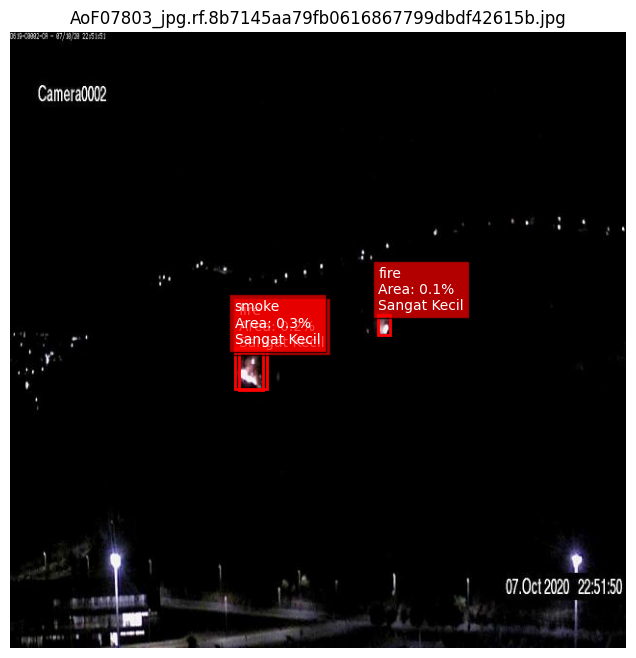

HASIL DETEKSI
Objek : smoke
Luas Bounding Box : 1386 pixel²
Persentase Area   : 0.34%
Kategori          : Sangat Kecil


In [45]:
import os
import random
import cv2
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# Folder train
image_dir = os.path.join(dataset_path, "train", "images")
label_dir = os.path.join(dataset_path, "train", "labels")

# Daftar gambar
image_files = [f for f in os.listdir(image_dir)
               if f.endswith((".jpg", ".jpeg", ".png"))]

# Pilih satu gambar secara acak
image_name = random.choice(image_files)

image_path = os.path.join(image_dir, image_name)
label_path = os.path.join(label_dir, os.path.splitext(image_name)[0] + ".txt")

# Baca gambar
image = cv2.imread(image_path)
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
h, w, _ = image.shape
image_area = w * h

# Nama kelas
class_names = ["fire", "smoke"]

# Plot gambar
def kategori_area(area_percent):
    if area_percent < 5:
        return "Sangat Kecil"
    elif area_percent < 15:
        return "Kecil"
    elif area_percent < 30:
        return "Sedang"
    elif area_percent < 50:
        return "Besar"
    else:
        return "Sangat Besar"
fig, ax = plt.subplots(figsize=(10, 8))
ax.imshow(image)

# Gambar bounding box
if os.path.exists(label_path):
    with open(label_path, "r") as f:
        for line in f:
            cls, x_center, y_center, bw, bh = map(float, line.split())

            # Konversi koordinat YOLO ke pixel
            x_center *= w
            y_center *= h
            bw *= w
            bh *= h

            x = x_center - bw / 2
            y = y_center - bh / 2
            box_area = bw * bh
            area_percent = (box_area / image_area) * 100
            status = kategori_area(area_percent)

            rect = patches.Rectangle(
                (x, y),
                bw,
                bh,
                linewidth=2,
                edgecolor='red',
                facecolor='none'
            )

            ax.add_patch(rect)

            label = (
                f"{class_names[int(cls)]}\n"
                f"Area: {area_percent:.1f}%\n"
                f"{status}"
            )

            ax.text(
                x,
                y-5,
                label,
                color="white",
                fontsize=10,
                bbox=dict(facecolor="red", alpha=0.7)
            )

plt.title(image_name)
plt.axis("off")
plt.show()
print("="*40)
print("HASIL DETEKSI")
print("="*40)
print(f"Objek : {class_names[int(cls)]}")
print(f"Luas Bounding Box : {box_area:.0f} pixel²")
print(f"Persentase Area   : {area_percent:.2f}%")
print(f"Kategori          : {status}")

In [46]:
from ultralytics import YOLO
import os

model = YOLO("yolov8n.pt")

results = model.train(
    data=os.path.join(dataset_path, "data.yaml"),
    epochs=50,
    imgsz=640,
    batch=16,
    device=0,
    workers=2,
    project="fire_smoke_training",
    name="yolov8n_fire_smoke",
    plots=True
)

Ultralytics 8.4.83 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/YOLOv9-fire-and-smoke-dataset-1/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dis=6.0, distill_model=None, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolov8n_fire_smoke, nbs=64, nms=False, opset=None, optimize=False, optimizer=au

In [48]:
metrics = model.val()
print(metrics)

Ultralytics 8.4.83 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 3,006,038 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1109.6±645.4 MB/s, size: 25.6 KB)
val: Scanning /content/YOLOv9-fire-and-smoke-dataset-1/valid/labels.cache... 460 images, 1 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 460/460 55.1Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 29/29 5.4it/s 5.4s
                   all        460        979      0.697      0.643      0.684      0.365
                  fire        219        539      0.686      0.599      0.651       0.33
                 smoke        404        440      0.707      0.686      0.716      0.399
Speed: 1.7ms preprocess, 4.5ms inference, 0.0ms loss, 1.3ms postprocess per image
Results saved to /content/runs/detect/val
ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: a

(np.float64(-0.5), np.float64(2399.5), np.float64(1199.5), np.float64(-0.5))

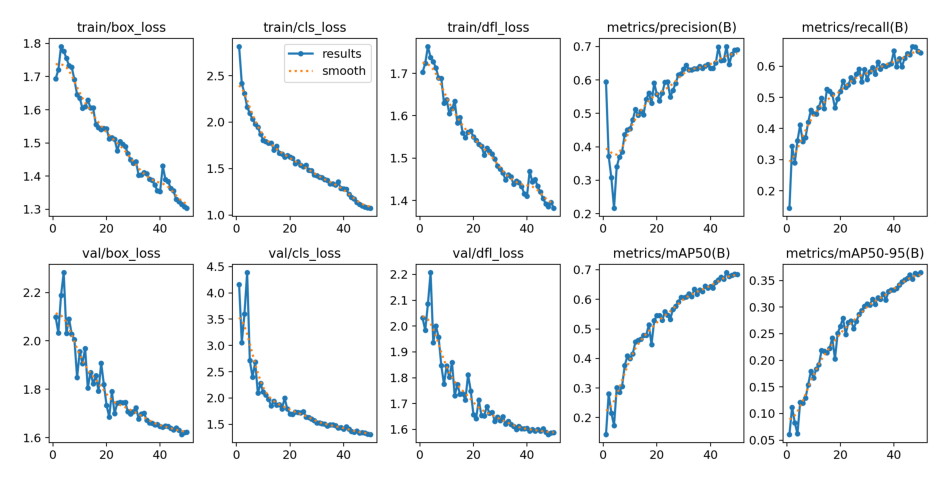

In [51]:
from PIL import Image
import matplotlib.pyplot as plt

plt.figure(figsize=(12,8))
plt.imshow(Image.open("/content/runs/detect/fire_smoke_training/yolov8n_fire_smoke/results.png"))
plt.axis("off")

In [57]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [58]:
import os

os.makedirs("/content/drive/MyDrive/ModelYOLO", exist_ok=True)

In [59]:
import shutil

source = "/content/runs/detect/fire_smoke_training/yolov8n_fire_smoke/weights/best.pt"
destination = "/content/drive/MyDrive/ModelYOLO/best.pt"

shutil.copy(source, destination)

print("Model berhasil disimpan ke Google Drive.")

Model berhasil disimpan ke Google Drive.


In [61]:
import os

os.makedirs("/content/drive/MyDrive/ModelYOLO", exist_ok=True)

In [63]:
from google.colab import files

files.download("/content/runs/detect/fire_smoke_training/yolov8n_fire_smoke/weights/best.pt")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>